# IMPLEMENTACION DE MODELOS BASE

**Autor: Abdias Figueredo V.**

**Version: 1.0**

**Agosto 2025**

**Cochabamba, Bolivia**

Índice maestro para el proyecto de pronóstico de demanda semanal

Definición del problema y métricas de éxito
1.1 Objetivo: pronóstico de NormalizedQuantity y/o OriginalQuantity por ItemCode a frecuencia semanal (StartWeek).
1.2 Horizonte(s) de pronóstico: p.ej., 4, 8, 12 semanas.
1.3 KPI de negocio: OTIF/Fill-rate, inventario objetivo, costo de stockout/overstock.
1.4 Métricas técnicas: sMAPE, MASE, RMSE; cobertura de intervalos.
1.5 Requisitos de latencia (batch vs. casi-real-time) y ventanas de actualización.

Gobernanza y comprensión de datos
2.1 Diccionario y contracts de datos: ItemCode, StartWeek, Week, OriginalQuantity, NormalizedQuantity, Price, LineTotal, AvailableStock.
2.2 Calidad: schema checks, tipos, duplicados por (ItemCode,StartWeek).
2.3 Trazabilidad: lineage desde origen hasta dataset modelable.
2.4 Políticas de versionado de datos (p.ej., DVC/Lakehouse time travel).

Preparación y limpieza (ETL/ELT reproducible)
3.1 Indexación temporal: usar StartWeek como índice Datetime (lunes ISO).
3.2 Completar calendario semanal por ítem (reindex con semanas faltantes).
3.3 Imputations controladas:
- Faltantes de demanda: 0 sólo si se confirma ausencia de ventas y no hubo stockout.
- Faltantes de Price y AvailableStock: forward-fill limitado con max gap.
3.4 Tratamiento de stockouts: marcar semanas con AvailableStock==0 o ventas truncadas (censura); flag para uso en modelado/filtrado.
3.5 Outliers: reglas robustas (IQR/Brute-Hampel) y winsorization opcional.
3.6 Transformaciones: log1p/Box-Cox si hay heterocedasticidad; normalizar precio si hay inflación (deflactar si aplica).
3.7 Train/validation/test por tiempo (sin fuga): definir cutoffs globales y por ítem.

Exploración y diagnóstico de series
4.1 Estacionalidades: semanal anual (52), promociones/eventos, tendencia.
4.2 Intermitencia: porcentaje de ceros por ítem; clasificar ítems (continuos vs. intermitentes).
4.3 Correlación y retrasos: lags de demanda y relación demanda-precio; elasticidad preliminar.
4.4 Efectos de censura por AvailableStock.

Ingeniería de features (respetando no-fuga)
5.1 Variables exógenas base: Price (y lags), rolling means de precio, price delta (%).
5.2 Calendario: feriados, paydays, estacionalidad anual, Black Friday, campañas.
5.3 Lags y rolling stats de demanda (lag 1..8, MA(4/8), std móviles).
5.4 Señales de disponibilidad (AvailableStock, stockout flag).
5.5 Codificación de nivel ítem: familia, categoría (si están disponibles).
5.6 Evitar fuga: construir features usando sólo info disponible hasta el cutoff.

Estrategia de particionado y backtesting
6.1 Rolling origin evaluation (ventanas expansivas o deslizantes).
6.2 Ventana de embargo si hay revisiones tardías de ventas.
6.3 Mínimo histórico por ítem (p.ej., ≥ 78 semanas) para modelos estacionales; reglas de fallback si no se cumple.

Modelos base y benchmarks
7.1 Naive y Seasonal Naive (SNAIVE, periodo 52) como línea base.
7.2 Comparar siempre contra benchmarks en cada backtest y por ítem.

Entrenamiento de modelos por ítem
8.1 ARIMA: diferenciación automática, selección (AICc/BIC), inspección de residuos.
8.2 ARIMAX (con Price): incluir lags/transformaciones de Price; verificar significancia y multicolinealidad.
8.3 ETS (Error-Trend-Seasonal): probar combinaciones (A/A, A/M, M/M) según transformaciones; elegir por AICc y backtests.
8.4 Holt-Winters (triple exponencial): aditivo vs. multiplicativo; optimización de α, β, γ y periodo 52.
8.5 Prophet: crecimiento lineal/logístico, estacionalidad anual semanal (52), feriados; agregar Price como regressor.
8.6 Manejo de intermitencia: si un ítem es altamente intermitente, aplicar regla de fallback (p.ej., Croston/TSB/SBA como referencia paralela) y documentar fuera del alcance principal.
8.7 Generación de intervalos de predicción coherentes (bootstrapping o analítico).

Búsqueda de hiperparámetros y model management
9.1 Grids acotados por item con early stopping por backtest; límites de tiempo por serie.
9.2 Paralelización por ítem (Dask/Spark/Ray) y caching de features.
9.3 Registro de experimentos (MLflow/W&B): parámetros, artefactos, métricas y figures.
9.4 Resource quotas y timeouts para evitar overruns en items difíciles.

Selección, ensembling y reglas de fallback
10.1 Champion per item: elegir el modelo con mejor MASE/sMAPE en el último split.
10.2 Blends simples (promedio ponderado) cuando mejoren la cobertura/calibración.
10.3 Reglas:
- Poco histórico → SNAIVE/ETS simple.
- Intermitente → fallback especializado.
- Exógena faltante → degradar de ARIMAX/Prophet-regressor a ARIMA/ETS.
10.4 Consistencia jerárquica (opcional): reconciliar por familia/categoría si existen.

Evaluación final y validación de negocio
11.1 Reporte por ítem y agregado: distribución de errores, worst-case tails.
11.2 Curvas de cobertura de intervalos y calibración.
11.3 What-ifs de precio: sensibilidad/elasticidad básica para ARIMAX/Prophet.
11.4 Revisión con stakeholders: casos con sesgo por censura de AvailableStock.

Empaquetado y reproducibilidad (MLOps básico)
12.1 Codebase modular (data, features, models, evaluation, serving).
12.2 Environments declarativos (conda/poetry) y lockfiles.
12.3 Versionado de datos/modelos: DVC + MLflow Model Registry.
12.4 Pruebas automáticas: unitarias (transformaciones), golden tests de métricas, tests de fuga temporal.
12.5 CI/CD: linter, tests, build, deploy (GitHub Actions/GitLab CI).

Orquestación y serving
13.1 Pipelines con Airflow/Prefect:
- Tareas: extract → validate → feature build → train → evaluate → register → forecast → publish.
13.2 Batch serving: generar pronósticos semanales para todos los ItemCode; almacenar en tabla de salidas con schema estable.
13.3 Real-time/near-real-time (opcional): endpoint para “what-if de Price” por ítem.
13.4 Contenerización (Docker) + empaquetado del modelo (MLflow pyfunc, ONNX si aplica).

Monitoreo y alertas en producción
14.1 Data quality: schema drift, tasas de nulos, rangos de Price/AvailableStock.
14.2 Prediction drift y error monitoring: sMAPE/MASE en ventana rodante.
14.3 Detección de cambio de régimen (rupturas) y concept drift.
14.4 Champion–Challenger: shadow deployment del retador y AB-tests por familia de ítems.
14.5 Alertas y SLOs: latencia, frescura de pronósticos, cobertura de intervalos.

Políticas de re-entrenamiento y lifecycle
15.1 Re-entrenar por calendario (p.ej., semanal/mensual) y por evento (drift).
15.2 Warm-start conservando hiperparámetros por ítem si no hay cambio de régimen.
15.3 Auto-retirement de modelos que no superen benchmarks por N ciclos.

Seguridad, cumplimiento y costos
16.1 Control de accesos a datos y secrets management.
16.2 Auditoría: lineage de predicciones (hash de datos, versión de modelo).
16.3 Optimización de costos: spot instances, caching, pruning de backtests para ítems de bajo impacto.

Documentación y playbooks
17.1 README técnico, runbooks de operación y playbook de incidentes.
17.2 Guía de uso para analistas y planificadores (interpretación de intervalos, límites).
17.3 Catálogo de features y supuestos (p.ej., tratamiento de censura por stock).

Roadmap de mejora
18.1 Enriquecer exógenas: promos, marketing spend, clima, competidores.
18.2 Pronóstico probabilístico completo (cuantiles) para políticas de inventario.
18.3 Reconciliación jerárquica y multi-item ensembling.
18.4 Causal uplift para decisiones de precio.
18.5 Intermitencia: incorporar TSB/Croston formalmente si el mix lo requiere.

## 1. INTRODUCCIÓN

---

## 2. CONFIGURACION INICIAL

### 2.1 Importación de librerías necesarias

In [ ]:
# #INSTALACION DE REQUIREMENTS
# #Comando alternativo: 
# #!pip install -r requirements.txt
# !pip install -r requirements.txt --quiet
# #pip install --only-binary :all: statsforecast

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'

[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# import os
# import sys

# def install_requirements():
#     """Instala dependencias desde requirements.txt de forma secuencial"""
#     req_path = os.path.join('..', 'requirements.txt')
    
#     if not os.path.exists(req_path):
#         print(f"⚠️ No se encontró {req_path}")
#         return False
    
#     try:
#         # Primero instalar numpy y dependencias base
#         !{sys.executable} -m pip install numpy pandas scipy --quiet
#         print("✅ Dependencias base instaladas")
        
#         # Luego el resto de dependencias
#         !{sys.executable} -m pip install -r {req_path} --quiet
#         print("✅ Todas las dependencias instaladas correctamente")
#         return True
        
#     except Exception as e:
#         print(f"❌ Error instalando dependencias: {e}")
#         return False

# # Instalar dependencias
# success = install_requirements()

✅ Dependencias base instaladas



[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


✅ Todas las dependencias instaladas correctamente



[notice] A new release of pip available: 22.3 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# IMPORTACION DE LIBRERIAS
# =============================================================================
# Manejo y procesamiento de datos
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import os
import scipy.stats as stats
from pandas.tseries.offsets import DateOffset

# Análisis de series temporales
# -----------------------------------------------------------------------------
from statsforecast import StatsForecast
from utilsforecast.plotting import plot_series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
import pmdarima as pm
import prophet

# Machine Learning
# -----------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import cohen_kappa_score

# Visualización
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Configuración de advertencias
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

# Configuración de estilos de visualización
# =============================================================================
# Configuración general de matplotlib
plt.style.use('classic')
plt.rcParams.update({
    'figure.figsize': (18, 7),
    'axes.facecolor': '#FFFFFF',  # Fondo blanco para mejor legibilidad
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 16
})

# Configuración de seaborn
#sns.set_theme(style="whitegrid", 
#              rc={'axes.facecolor': '#FFFFFF'},
#              font_scale=1.1)

c:\Users\abdia\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


### 2.2 Carga de datos

In [2]:
# CARGA DE DATOS dfWeekStock
dataFactWeekSales = pd.read_parquet('../data/gold/FactWeekSales.parquet')
dfFactWeekSales = dataFactWeekSales.copy()
dfFactWeekSales.head()

,ItemCode,StartWeek,Week,OriginalQuantity,NormalizedQuantity,Price,LineTotal,AvailableStock,DemandStockout
0,SKU-00750,2018-01-01,2018-W01,0.0,0.0,368.27,0.00,102.0,0
1,SKU-00750,2018-01-08,2018-W02,0.0,0.0,368.27,0.00,102.0,0
2,SKU-00750,2018-01-15,2018-W03,7.0,7.0,368.27,2577.89,95.0,0
3,SKU-00750,2018-01-22,2018-W04,0.0,0.0,368.27,0.00,95.0,0
4,SKU-00750,2018-01-29,2018-W05,0.0,0.0,368.27,0.00,95.0,0


---

In [8]:
# import pandas as pd
# import numpy as np
# from statsmodels.tsa.holtwinters import ExponentialSmoothing
# from pmdarima import auto_arima
# from prophet import Prophet
# from sklearn.metrics import mean_squared_error

# # ==============================
# # 1) Métricas
# # ==============================
# def mase(y_true, y_pred, y_train):
#     """Mean Absolute Scaled Error"""
#     n = len(y_train)
#     d = np.mean(np.abs(np.diff(y_train)))
#     errors = np.abs(y_true - y_pred)
#     return errors.mean() / d if d != 0 else np.nan

# def smape(y_true, y_pred):
#     """Symmetric Mean Absolute Percentage Error"""
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / denominator
#     diff[denominator == 0] = 0.0
#     return np.mean(diff) * 100

# def rmse(y_true, y_pred):
#     return np.sqrt(mean_squared_error(y_true, y_pred))

# # ==============================
# # 2) Split temporal
# # ==============================
# def temporal_split(df, date_col="StartWeek", target_col="NormalizedQuantity", split=(0.7, 0.15, 0.15)):
#     """Divide en train, val, test respetando orden temporal"""
#     df = df.sort_values(date_col)
#     n = len(df)
#     train_end = int(n * split[0])
#     val_end = train_end + int(n * split[1])
    
#     train = df.iloc[:train_end]
#     val = df.iloc[train_end:val_end]
#     test = df.iloc[val_end:]
#     return train, val, test

# # ==============================
# # 3) Modelos individuales
# # ==============================
# def train_arima(y_train, y_val):
#     model = auto_arima(y_train, seasonal=True, m=5,
#                        error_action="ignore", suppress_warnings=True)
#     return model.predict(n_periods=len(y_val))

# def train_arimax(y_train, y_val, exog_train, exog_val):
#     model = auto_arima(y_train, exogenous=exog_train,
#                        seasonal=True, m=52,
#                        error_action="ignore", suppress_warnings=True)
#     return model.predict(n_periods=len(y_val), exogenous=exog_val)

# def train_holt_winters(y_train, y_val):
#     model = ExponentialSmoothing(y_train, trend="add", seasonal="add", seasonal_periods=52)
#     fit = model.fit()
#     return fit.forecast(len(y_val))

# def train_prophet(train, val, date_col="StartWeek"):
#     prophet_df = train.rename(columns={date_col: "ds", "NormalizedQuantity": "y"})
#     prophet_df["Price"] = train["Price"].values
    
#     m = Prophet(weekly_seasonality=False, yearly_seasonality=True)
#     m.add_regressor("Price")
#     m.fit(prophet_df)
    
#     future = val.rename(columns={date_col: "ds"})
#     future["Price"] = val["Price"].values
#     forecast = m.predict(future)
#     return forecast["yhat"].values

# # ==============================
# # 4) Evaluación
# # ==============================
# def evaluate_models(y_train, y_val, preds):
#     metrics = {}
#     for name, pred in preds.items():
#         metrics[name] = {
#             "MASE": mase(y_val, pred, y_train),
#             "sMAPE": smape(y_val, pred),
#             "RMSE": rmse(y_val, pred)
#         }
#     return metrics

# # ==============================
# # 5) Pipeline por ítem
# # ==============================
# def train_models_item(df_item, item_code, date_col="StartWeek"):
#     """Entrena todos los modelos para un ítem y devuelve métricas"""
#     train, val, test = temporal_split(df_item, date_col=date_col)
#     y_train, y_val = train["NormalizedQuantity"].values, val["NormalizedQuantity"].values
    
#     preds = {}
#     preds["ARIMA"] = train_arima(y_train, y_val)
#     preds["ARIMAX"] = train_arimax(y_train, y_val, train[["Price"]].values, val[["Price"]].values)
#     preds["Holt-Winters"] = train_holt_winters(y_train, y_val)
#     preds["Prophet"] = train_prophet(train, val, date_col=date_col)
    
#     metrics = evaluate_models(y_train, y_val, preds)
    
#     return {
#         "ItemCode": item_code,
#         "metrics": metrics,
#         "predictions": preds,
#         "splits": (train, val, test)
#     }

# # ==============================
# # 6) Pipeline para todos los ítems
# # ==============================
# def train_all_items(df, date_col="StartWeek"):
#     results = []
#     for item_code, df_item in df.groupby("ItemCode"):
#         res = train_models_item(df_item, item_code, date_col=date_col)
        
#         # elegir mejor modelo por MASE
#         metrics_df = pd.DataFrame(res["metrics"]).T
#         best_model = metrics_df["MASE"].idxmin()
        
#         results.append({
#             "ItemCode": item_code,
#             "BestModel": best_model,
#             "Metrics": res["metrics"]
#         })
    
#     return pd.DataFrame(results)


In [9]:
# # ==============================
# # 7) Ejemplo de uso
# # ==============================
# result_df = train_all_items(dfFactWeekSales)
# print(result_df)


In [ ]:
# item_code = "SKU-00750"
# df_item = dfFactWeekSales[dfFactWeekSales["ItemCode"] == item_code]

In [ ]:
# # ==============================
# # 7) Ejemplo de uso
# # ==============================
# result_df = train_all_items(df_item)
# print(result_df)


22:58:41 - cmdstanpy - INFO - Chain [1] start processing
22:58:42 - cmdstanpy - INFO - Chain [1] done processing


    ItemCode BestModel                                            Metrics
0  SKU-00750    ARIMAX  {'ARIMA': {'MASE': 1.2321886542213984, 'sMAPE'...


## 3. SPLIT TRAIN/VALID/TEST

In [ ]:
# FUNCION SPLIT TRAIN VAL TEST

def temporal_split(
    df, 
    date_col="StartWeek", 
    target_col="NormalizedQuantity", 
    split=(0.7, 0.15, 0.15)):
    """
    Divide un DataFrame en train, validation y test respetando el orden temporal.
    
    Parámetros
    ----------
    df : pd.DataFrame
        Datos de un único ItemCode con columnas de fecha y target.
    date_col : str, default="StartWeek"
        Nombre de la columna con la fecha (se ordena por esta columna).
    target_col : str, default="NormalizedQuantity"
        Nombre de la variable objetivo.
    split : tuple, default=(0.7, 0.15, 0.15)
        Proporciones de train, validation y test (deben sumar 1).
    
    Retorna
    -------
    train : pd.DataFrame
    val   : pd.DataFrame
    test  : pd.DataFrame
    """
    
    # Asegurar orden temporal
    df = df.sort_values(date_col).reset_index(drop=True)
    
    n = len(df)
    train_end = int(n * split[0])
    val_end = train_end + int(n * split[1])
    
    train = df.iloc[:train_end]
    val = df.iloc[train_end:val_end]
    test = df.iloc[val_end:]
    
    return train, val, test


In [11]:
# # Filtrar un ítem de ejemplo
# item_code = "ITEM123"
# df_item = dfFactWeekSales[dfFactWeekSales["ItemCode"] == item_code]

# Hacer el split
train, val, test = temporal_split(dfFactWeekSales)

print(f"Tamaño total: {len(df_item)}")
print(f"Train: {len(train)}, Validation: {len(val)}, Test: {len(test)}")

print("Rango de fechas:")
print("Train:", train["StartWeek"].min(), "→", train["StartWeek"].max())
print("Val  :", val["StartWeek"].min(), "→", val["StartWeek"].max())
print("Test :", test["StartWeek"].min(), "→", test["StartWeek"].max())


Tamaño total: 396
Train: 1794870, Validation: 384615, Test: 384615
Rango de fechas:
Train: 2018-01-01 00:00:00 → 2023-04-24 00:00:00
Val  : 2023-04-24 00:00:00 → 2024-06-10 00:00:00
Test : 2024-06-10 00:00:00 → 2025-07-28 00:00:00


In [ ]:
# FUNCION DE GRAFICO 

import matplotlib.pyplot as plt

def plot_temporal_split(train, val, test, date_col="StartWeek", target_col="NormalizedQuantity", item_code=None):
    """
    Visualiza gráficamente el split temporal (train, validation, test).
    
    Parámetros
    ----------
    train, val, test : pd.DataFrame
        Particiones obtenidas del split.
    date_col : str
        Nombre de la columna temporal.
    target_col : str
        Columna de la variable objetivo.
    item_code : str or None
        Código del ítem (opcional, para título).
    """
    
    plt.figure(figsize=(12, 6))

    # Graficar cada conjunto
    plt.plot(train[date_col], train[target_col], label="Train", color="blue")
    plt.plot(val[date_col], val[target_col], label="Validation", color="orange")
    plt.plot(test[date_col], test[target_col], label="Test", color="green")

    # Título
    title = f"Temporal Split - Item {item_code}" if item_code else "Temporal Split"
    plt.title(title, fontsize=14)

    plt.xlabel("Fecha", fontsize=12)
    plt.ylabel(target_col, fontsize=12)
    plt.legend()
    plt.grid(True)
    plt.show()


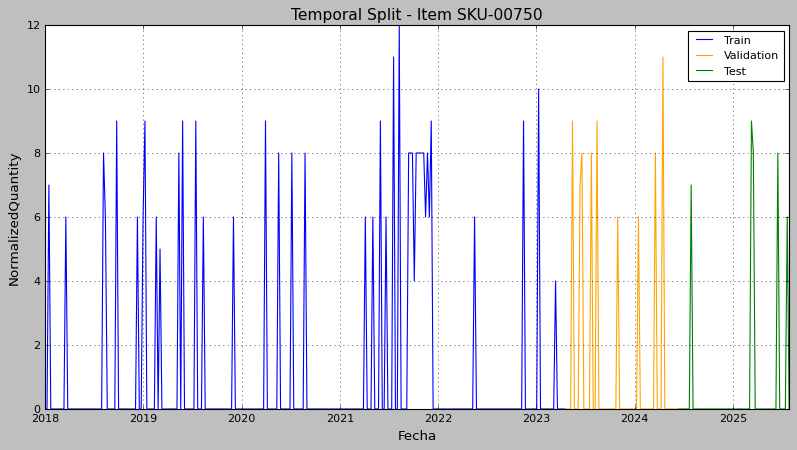

In [21]:
# Filtrar un ítem
item_code = "SKU-00750"
df_item = dfFactWeekSales[dfFactWeekSales["ItemCode"] == item_code]

# Split temporal
train, val, test = temporal_split(df_item)

# Visualización
plot_temporal_split(train, val, test, item_code=item_code)


## 4. ESTIMACION DEL MODELO

In [25]:
# FUNCION TRAIN ARIMA

def train_arima_item(df_item, date_col="StartWeek"):
    """
    Entrena ARIMA para un solo ítem y devuelve resultados.
    
    Parámetros
    ----------
    df_item : pd.DataFrame
        Sub-dataframe correspondiente a un ItemCode.
    date_col : str
        Nombre de la columna de fecha.
    
    Retorna
    -------
    dict
        {
            "ItemCode": str,
            "y_val": np.array,
            "preds_val": np.array,
            "model": modelo entrenado,
            "train": df_train,
            "val": df_val,
            "test": df_test
        }
    """
    # Ordenar por fecha
    df_item = df_item.sort_values(date_col)
    
    # Split temporal
    train, val, test = temporal_split(df_item, date_col=date_col)
    y_train = train["NormalizedQuantity"].values
    y_val   = val["NormalizedQuantity"].values
    
    # Entrenar ARIMA
    model = auto_arima(y_train,
                       seasonal=True, m=5,
                       max_p=3,
                       max_q=3,
                       max_P=3,
                       max_Q=3,
                       #d='tdf',
                       stepwise=True,
                       suppress_warnings=True,
                       error_action="ignore")
    
    preds = model.predict(n_periods=len(y_val))
    
    return {
        "ItemCode": df_item["ItemCode"].iloc[0],
        "y_val": y_val,
        "preds_val": preds,
        "model": model,
        "train": train,
        "val": val,
        "test": test
    }


In [26]:
# Aplicar ARIMA a cada ItemCode
results_arima = dfFactWeekSales.groupby("ItemCode").apply(train_arima_item)

# results_arima será una Serie de dicts → podemos convertirla a dataframe
results_arima = results_arima.reset_index(drop=True)


KeyboardInterrupt: 

## 5. VALIDACION DEL MODELO

### 6.1 DIMENSION PRODUCTOS

In [24]:
DimItems=dfOITM
print("\nDimensión de Items:")
DimItems.head(10)


Dimensión de Items:


,ItemCode,ItemName,Brand,Category,CreateDate,FrozenFor,ItemGrp
0,SKU-00000,Recent bad Part,Wilson-Simpson,transform,2019-02-20 16:49:31,Y,447
1,SKU-00001,Activity call Part,Osborne Inc,synthesize,2016-10-17 15:36:27,Y,447
2,SKU-00002,Son almost Part,Galloway-Ray,synergize,2016-07-09 01:27:57,Y,447
3,SKU-00003,Decade create Part,Gutierrez Ltd,extend,2016-10-06 21:36:24,Y,447
4,SKU-00004,Hair concern Part,"Miles, Sharp and Davis",synergize,2017-12-01 12:37:55,Y,447
5,SKU-00005,Thing fly Part,"Baker, Hudson and Daniels",grow,2016-05-13 15:11:52,Y,447
6,SKU-00006,Brother seek Part,Robinson-Shannon,architect,2017-04-07 00:34:46,Y,447
7,SKU-00007,Tend success Part,Brown-Myers,productize,2016-03-01 08:43:45,Y,447
8,SKU-00008,Money region Part,Key-Reyes,target,2017-02-06 19:48:22,Y,447
9,SKU-00009,Product just Part,"Perry, Alexander and Brewer",aggregate,2017-09-29 12:00:39,Y,447


In [25]:
# MERGE DE DATAFRAMES DFWEEKSALES Y DFWEEKSALESSTOCKOUT
DimSubItems = pd.merge(
    dfSegmentation[['ItemCode','Mean','SD','CV2','ADI','DemandPattern']],
    dfABC[['ItemCode','LineTotal','Percentage','CumulativePercentage','ABC']],
    on=['ItemCode'],
    how='left'
)
DimSubItems.head(10)

,ItemCode,Mean,SD,CV2,ADI,DemandPattern,LineTotal,Percentage,CumulativePercentage,ABC
0,SKU-00750,7.59,1.64,0.05,7.07,Intermittent,13802.90,0.01,90.45,C
1,SKU-00751,8.20,1.95,0.06,8.61,Intermittent,27742.36,0.01,74.86,B
2,SKU-00752,8.31,8.20,0.97,2.29,Lumpy,28958.19,0.01,74.28,B
3,SKU-00754,7.15,2.10,0.09,10.15,Intermittent,5613.47,0.00,99.27,C
4,SKU-00756,7.26,1.32,0.03,4.30,Intermittent,2673.52,0.00,99.94,C
5,SKU-00757,8.67,2.54,0.09,8.80,Intermittent,13778.86,0.01,90.48,C
6,SKU-00760,7.60,1.75,0.05,7.47,Intermittent,4788.73,0.00,99.62,C
7,SKU-00761,7.69,1.88,0.06,7.62,Intermittent,16643.28,0.01,85.92,C
8,SKU-00764,6.76,4.54,0.45,1.57,Intermittent,58494.96,0.03,57.14,B
9,SKU-00765,7.69,2.31,0.09,7.62,Intermittent,10546.05,0.01,95.10,C


## 7. FORECAST DEL MODELO

In [26]:
# GUARDAR EL DATAFRAME PROCESADO DFStock
DimSubItems.to_parquet('../data/gold/DimSubItems.parquet', index=False)

In [27]:
# GUARDAR EL DATAFRAME PROCESADO DFStock
DimItems.to_parquet('../data/gold/DimItems.parquet', index=False)

## 6. CONCLUSIONES

- Se identificaron que los productos mas vendidos son los SKUs 06074, 03543 y 03063.
- El análisis de distribución mostró que las ventas semanales no siguen una distribución normal (p-valor < 0.05 en la prueba de Shapiro-Wilk), lo que es común en datos de ventas del mundo real debido a factores externos como promociones o eventos estacionales.
- El analisis de outliers mostro que hay 2 valoes atipicos en la variable ventas semanales. Es coveniente normalizar estos datos ya que el proximo paso sera crear un modelo de pronostico.